# Notebook 05 - Animated Visualisations

The static figures in Notebooks 02-04 establish the results. This notebook
re-tells the three central findings as **animations**, which make the
dose-response dynamic legible in a way a still frame cannot: the viewer *sees*
the distribution move.

Each animation is written to `reports/animations/` as a self-contained GIF (no
external dependencies - rendered with Matplotlib's `PillowWriter`) and displayed
inline. The GIFs are share-ready for posts or slides.

- **Animation 1** - the skill-retention distribution as the GenAI-usage window
  sweeps from light to heavy, tracing the inverted-U in real time.
- **Animation 2** - grade improvement by use case, revealing that purpose, not
  volume, separates outcomes.
- **Animation 3** - the fitted quadratic being drawn over the data, with the
  optimum dropping into place.

In [1]:
# Standard library
import warnings
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project paths (notebooks live in notebooks/, data one level up)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_CSV = ROOT / "data" / "ai_student_impact_dataset (1).csv"
PROC_DIR = ROOT / "data" / "processed"
PROC_CSV = PROC_DIR / "students_clean.csv"
FIG_DIR = ROOT / "reports" / "figures"
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 3.0.3 | numpy 2.5.1


In [2]:
# ----------------------------------------------------------------------
# Visual system: one colour-vision-safe palette used across every figure.
# Categorical hues are assigned in a fixed order (never cycled); sequential
# encodings use a single-hue blue ramp; diverging encodings use blue<->red
# with a neutral midpoint. Grids are recessive and marks are thin.
# ----------------------------------------------------------------------
PALETTE = {
    "blue":    "#2a78d6", "aqua":   "#1baf7a", "yellow":  "#eda100",
    "green":   "#008300", "violet": "#4a3aa7", "red":     "#e34948",
    "magenta": "#e87ba4", "orange": "#eb6834",
}
CAT = list(PALETTE.values())

INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
GOOD, WARN, SERIOUS, CRITICAL = "#0ca30c", "#fab219", "#ec835a", "#d03b3b"

# Ordered status colours for Low / Medium / High categories
RISK_COLORS = {"Low": GOOD, "Medium": WARN, "High": CRITICAL}

# Single-hue sequential ramp (magnitude) and blue<->red diverging ramp (polarity)
_SEQ = ["#eaf2fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", _SEQ)
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_red", ["#184f95", "#6da7ec", "#f0efec", "#e88a89", "#c0332f"]
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110, "savefig.dpi": 150,
    "font.size": 11, "font.family": "sans-serif",
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelcolor": INK_SOFT, "axes.labelsize": 10.5,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.0, "lines.markersize": 7,
})

def style_axis(ax):
    """Recessive grid on y only; clean baseline."""
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", visible=True)
    for s in ("left",):
        ax.spines[s].set_color(BASELINE)
    return ax

sns.set_style("white")
print("Visual system ready:", len(CAT), "categorical hues.")


Visual system ready: 8 categorical hues.


In [3]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

ANIM_DIR = ROOT / "reports" / "animations"
ANIM_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC_CSV)
GIF_DPI, GIF_FPS = 90, 18
print(f"Loaded {df.shape[0]:,} rows. GIFs -> {ANIM_DIR.relative_to(ROOT)}")

Loaded 50,000 rows. GIFs -> reports/animations


## Animation 1 - The moving distribution (the inverted-U in motion)

A sliding window scans students ordered by weekly GenAI hours. The left panel
shows the skill-retention distribution *inside* the current window; the right
panel traces the window's mean as the window advances. The distribution visibly
shifts right, peaks at moderate use, then slides back - the inverted-U, animated.

saved anim1_moving_distribution.gif


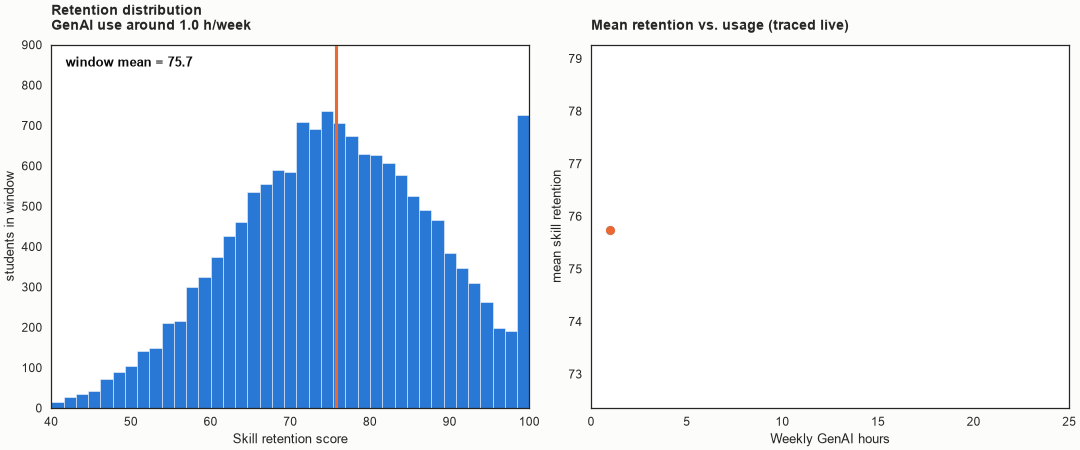

In [4]:
# Precompute the sliding-window curve (window half-width = 2h)
centers = np.arange(1.0, 24.1, 0.5)
half = 2.0
curve_x, curve_y = [], []
for cx in centers:
    w = df.loc[df["Weekly_GenAI_Hours"].between(cx - half, cx + half), "Skill_Retention_Score"]
    curve_x.append(cx); curve_y.append(w.mean())
curve_x, curve_y = np.array(curve_x), np.array(curve_y)
peak_i = int(np.nanargmax(curve_y))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

def frame1(i):
    cx = centers[i]
    win = df.loc[df["Weekly_GenAI_Hours"].between(cx - half, cx + half), "Skill_Retention_Score"]
    axL.clear(); axR.clear()
    # Left: distribution within window
    axL.hist(win, bins=np.linspace(40, 100, 40), color=PALETTE["blue"],
             edgecolor=SURFACE, linewidth=0.4)
    axL.axvline(win.mean(), color=PALETTE["orange"], lw=2.5)
    axL.set_xlim(40, 100); axL.set_ylim(0, 900)
    axL.set_title(f"Retention distribution\nGenAI use around {cx:.1f} h/week", fontsize=11)
    axL.set_xlabel("Skill retention score"); axL.set_ylabel("students in window")
    axL.grid(axis="x", visible=False)
    axL.text(0.03, 0.94, f"window mean = {win.mean():.1f}", transform=axL.transAxes,
             fontsize=10, color=INK, fontweight="bold")
    # Right: mean traced so far
    axR.plot(curve_x[:i+1], curve_y[:i+1], "-", color=PALETTE["blue"], lw=2.6)
    axR.scatter([cx], [curve_y[i]], s=70, color=PALETTE["orange"], zorder=5,
                edgecolor=SURFACE, linewidth=1)
    if i >= peak_i:
        axR.scatter([curve_x[peak_i]], [curve_y[peak_i]], s=90, facecolor="none",
                    edgecolor=CRITICAL, linewidth=2, zorder=4)
        axR.annotate(f"optimum ~ {curve_x[peak_i]:.0f} h", (curve_x[peak_i], curve_y[peak_i]),
                     xytext=(curve_x[peak_i] + 1, curve_y[peak_i] - 2.2), color=INK,
                     fontsize=10, fontweight="bold")
    axR.set_xlim(0, 25); axR.set_ylim(np.nanmin(curve_y) - 1, np.nanmax(curve_y) + 2)
    axR.set_title("Mean retention vs. usage (traced live)", fontsize=11)
    axR.set_xlabel("Weekly GenAI hours"); axR.set_ylabel("mean skill retention")
    axR.grid(axis="x", visible=False)
    return axL, axR

anim1 = FuncAnimation(fig, frame1, frames=len(centers), interval=1000/GIF_FPS)
gif1 = ANIM_DIR / "anim1_moving_distribution.gif"
anim1.save(gif1, writer=PillowWriter(fps=GIF_FPS), dpi=GIF_DPI)
plt.close(fig)
print("saved", gif1.name)
display(Image(filename=str(gif1)))

**Reading it.** As the window moves from light to moderate use, the entire
retention distribution drifts upward and the mean rises. Past the optimum near
9 hours, the distribution slides back and thins on the right - heavy users retain
less. The effect is a property of the whole population, not a few outliers.

## Animation 2 - Purpose beats volume

Grade improvement by primary use case, with each bar growing to its value. The
cognitive-offloading pattern (direct answer generation) is held in red and
settles at the bottom; analytic uses rise above it.

saved anim2_use_case_race.gif


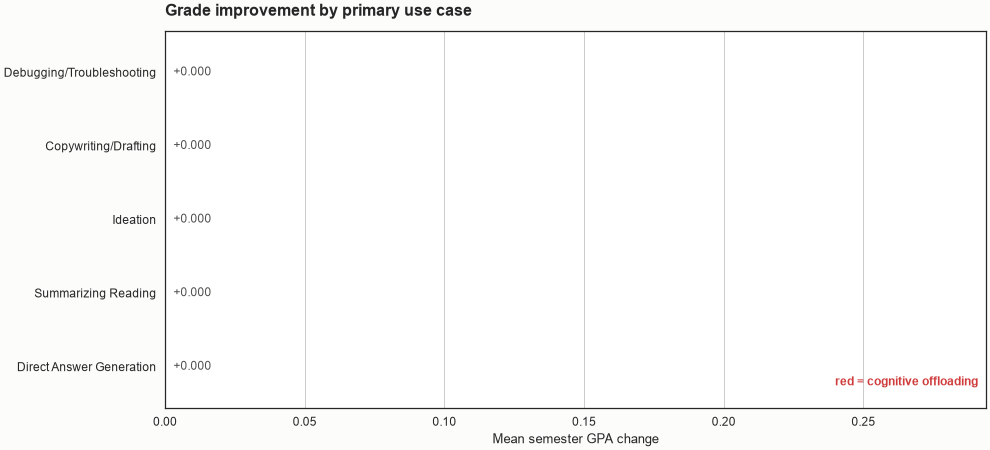

In [5]:
uc = df.groupby("Primary_Use_Case")["GPA_Delta"].mean().sort_values()
labels = [u.replace("_", " ") for u in uc.index]
finals = uc.values
colors = [CRITICAL if u == "Direct_Answer_Generation" else PALETTE["aqua"] for u in uc.index]

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
n2 = 46
def smooth(t):  # ease-in-out
    return t * t * (3 - 2 * t)

def frame2(i):
    f = smooth(min(i / (n2 - 8), 1.0))
    ax.clear()
    heights = finals * f
    ax.barh(range(len(finals)), heights, color=colors, height=0.66)
    for j, h in enumerate(heights):
        ax.text(h + 0.003, j, f"{h:+.3f}", va="center", fontsize=9.5, color=INK_SOFT)
    ax.set_yticks(range(len(finals))); ax.set_yticklabels(labels)
    ax.set_xlim(0, finals.max() * 1.18)
    ax.set_xlabel("Mean semester GPA change")
    ax.set_title("Grade improvement by primary use case")
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.text(0.99, 0.06, "red = cognitive offloading", transform=ax.transAxes,
            ha="right", color=CRITICAL, fontsize=9.5, fontweight="bold")
    return (ax,)

anim2 = FuncAnimation(fig, frame2, frames=n2, interval=1000/GIF_FPS)
gif2 = ANIM_DIR / "anim2_use_case_race.gif"
anim2.save(gif2, writer=PillowWriter(fps=GIF_FPS), dpi=GIF_DPI)
plt.close(fig)
print("saved", gif2.name)
display(Image(filename=str(gif2)))

**Reading it.** Every use case lifts grades on average, but they do not lift
them equally. Direct answer generation, the purest offloading, is reliably the
weakest; debugging and ideation lead. Same tool, different cognitive work,
different result.

## Animation 3 - Fitting the optimum

The binned observed means (static points) with the fitted quadratic drawn across
them left to right. When the curve completes, its vertex - the estimated optimal
usage - drops into place.

saved anim3_quadratic_fit.gif


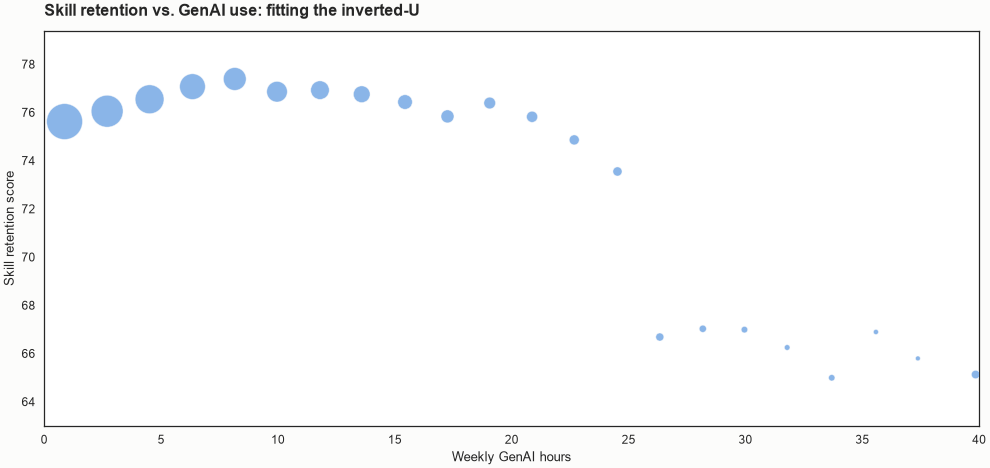

In [6]:
from numpy.polynomial import polynomial as P
d3 = df.copy()
d3["hb"] = pd.cut(d3["Weekly_GenAI_Hours"], bins=22)
binned = d3.groupby("hb", observed=True).agg(
    x=("Weekly_GenAI_Hours", "mean"), y=("Skill_Retention_Score", "mean"), n=("hb", "size")).dropna()
b0, b1, b2 = np.polyfit(df["Weekly_GenAI_Hours"], df["Skill_Retention_Score"], 2)[::-1]
vertex = -b1 / (2 * b2)
xs = np.linspace(0, df["Weekly_GenAI_Hours"].quantile(0.995), 240)
ys = b0 + b1 * xs + b2 * xs**2

fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
n3 = 56
def frame3(i):
    ax.clear()
    ax.scatter(binned["x"], binned["y"], s=binned["n"] / 12, color=PALETTE["blue"],
               alpha=0.55, edgecolor=SURFACE, linewidth=0.6, zorder=3)
    reveal = min(int((i / (n3 - 12)) * len(xs)), len(xs))
    ax.plot(xs[:reveal], ys[:reveal], color=PALETTE["orange"], lw=2.8, zorder=4)
    if i >= n3 - 12:
        ax.axvline(vertex, color=INK_SOFT, ls="--", lw=1.6)
        ax.scatter([vertex], [b0 + b1*vertex + b2*vertex**2], s=120, color=CRITICAL,
                   zorder=6, edgecolor=SURFACE, linewidth=1.2)
        ax.text(vertex + 0.4, ax.get_ylim()[0] + 1.2, f"optimum ~ {vertex:.1f} h/week",
                color=INK, fontsize=11, fontweight="bold")
    ax.set_xlim(0, xs.max()); ax.set_ylim(binned["y"].min() - 2, binned["y"].max() + 2)
    ax.set_xlabel("Weekly GenAI hours"); ax.set_ylabel("Skill retention score")
    ax.set_title("Skill retention vs. GenAI use: fitting the inverted-U")
    ax.grid(axis="x", visible=False)
    return (ax,)

anim3 = FuncAnimation(fig, frame3, frames=n3, interval=1000/GIF_FPS)
gif3 = ANIM_DIR / "anim3_quadratic_fit.gif"
anim3.save(gif3, writer=PillowWriter(fps=GIF_FPS), dpi=GIF_DPI)
plt.close(fig)
print("saved", gif3.name)
display(Image(filename=str(gif3)))

**Reading it.** The parabola tracks the observed means and turns over near
9 weekly hours - the same optimum the formal quadratic regression in Notebook 03
estimates. The animation is a visual restatement of that statistical result.

## Summary

Three GIFs, one message: student skill retention is a non-monotonic function of
GenAI intensity, and the pattern is a property of the whole population. The files
in `reports/animations/` are standalone and can be dropped into a post or a
presentation. For the underlying statistics, see Notebook 03.